# Surface Water Fraction Model Training

End-to-end regression pipeline: physics baseline → preprocessing → model selection → feature study → hyperparameter optimisation → explainability → pruning → generalisation → error analysis → final model.

## 1. Initial Setup

Load all required libraries, define canonical constants, register all utility functions, and load the raw dataset. Every downstream section imports variables defined here — nothing is redefined in later sections.

- **Feature sets used:** not yet (constants only)
- **Models used:** not yet (helper definitions only)
- **Why:** centralising setup guarantees reproducibility and avoids silent redefinitions.

In [1]:
import json
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import warnings
import xarray as xr
import xgboost as xgb

from lightgbm import LGBMRegressor
from scipy import stats
from scipy.linalg import LinAlgWarning
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, ElasticNet

# ── Reproducibility ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
TARGET_COL = 'fwns'
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
np.random.seed(RANDOM_STATE)

# ── Canonical feature sets ───────────────────────────────────────────
REFERENCE_FEATURE_SET = [
    'tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H',
    'tran19V', 'tbup19V', 'tran37V', 'tbup37V',
    'surtep_ERA5', 'vsm', 'VOD',
]  # Used as the fixed feature set for preprocessing and model selection studies.

FULL_FEATURE_SET = [
    'tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H',
    'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H',
    'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V',
    'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V',
    'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD',
    'clase', 'porcentaje clase', 'day', 'latitude_grid', 'longitude_grid']

# ── Model selection study constants ────────────────────────────────
MODEL_SELECTION_N_TRIALS = 25
MODEL_SELECTION_N_SPLITS = 3
MODEL_SELECTION_SAMPLE_FRAC = 0.1

# ── Full HPO constants ──────────────────────────────────────────────
TUNING_N_TRIALS = 50
TUNING_EARLY_STOPPING = 50
TUNING_N_SPLITS = 5
TUNING_SAMPLE_FRAC = 0.3

# ── Final exhaustive HPO constants ────────────────────────────────
FINAL_HPO_N_TRIALS = 200
FINAL_HPO_N_SPLITS = 5
FINAL_HPO_EARLY_STOPPING = 100

# ── Final CV / pruning constants ─────────────────────────────────
FINAL_CV_N_SPLITS = 5
RFECV_SAMPLE_FRAC = 0.25
RFECV_TOL = 0.005  # Accept fewest features within 0.5 % relative RMSE of the best CV score
SHAP_THRESHOLD = 0.00125

# ── Directory constants ─────────────────────────────────────────────
HPO_DIR = 'HPO_results'
MODEL_DIR = 'models'

# ── Suppressing warnings ───────────────────────────────────────────
warnings.filterwarnings('ignore', category=LinAlgWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)


In [2]:
# ============================================================
# UTILITY FUNCTIONS — do not modify below this line
# ============================================================
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}
    iterator = models.items() if isinstance(models, dict) else models

    for name, model in tqdm(iterator, desc='Training models'):
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results_all[name] = {
            'MAE_train': mean_absolute_error(y_train, y_pred_train),
            'MSE_train': mean_squared_error(y_train, y_pred_train),
            'R2_train': r2_score(y_train, y_pred_train),
            'MAE_test': mean_absolute_error(y_test, y_pred_test),
            'MSE_test': mean_squared_error(y_test, y_pred_test),
            'R2_test': r2_score(y_test, y_pred_test),
            'time_s': round(elapsed_time, 4),
        }

    return results_all

def preprocess_dataset(df_in, target_col=TARGET_COL, remove_zeros=False, boxcox_target=False, scale_features=False):
    df_out = df_in.copy()
    boxcox_lambda = None

    if remove_zeros:
        df_out = df_out[df_out[target_col] != 0].copy()

    if boxcox_target:
        if (df_out[target_col] <= 0).any():
            raise ValueError('Box-Cox requires strictly positive target values.')
        df_out[target_col], boxcox_lambda = stats.boxcox(df_out[target_col])

    if scale_features:
        feature_cols = df_out.columns.drop(target_col)
        scaler = StandardScaler()
        df_out[feature_cols] = scaler.fit_transform(df_out[feature_cols])

    return df_out, boxcox_lambda

def evaluate_scaling_variants(df_raw, variants, models, target_col=TARGET_COL):
    rows = []

    for variant_name, params in tqdm(variants.items(), desc='Scaling variants'):
        df_variant, lam = preprocess_dataset(df_raw, target_col=target_col, **params)
        y_variant = df_variant[target_col]

        tr_idx = df_variant.index[df_raw.loc[df_variant.index, 'year'] == 2017]
        te_idx = df_variant.index[df_raw.loc[df_variant.index, 'year'] == 2018]

        df_variant = df_variant.drop(columns=['year'])

        X_train = df_variant.drop(columns=[target_col]).loc[tr_idx]
        X_test = df_variant.drop(columns=[target_col]).loc[te_idx]
        y_train = y_variant.loc[tr_idx]
        y_test = y_variant.loc[te_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            row = {
                'variant': variant_name,
                'model': model_name,
                'rows': len(df_variant),
                'boxcox_lambda': np.nan if lam is None else lam,
                **values,
            }
            rows.append(row)

    return pd.DataFrame(rows)

def evaluate_feature_sets(df_model, y, train_idx, test_idx, feature_sets, models):
    all_rows = []

    for set_name, features in tqdm(feature_sets.items(), desc='Feature sets'):
        X_train = df_model.loc[train_idx, features]
        X_test = df_model.loc[test_idx, features]
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            all_rows.append({
                'feature_set': set_name,
                'n_features': len(features),
                'model': model_name,
                **values,
            })

    return pd.DataFrame(all_rows)

def compute_shap_importance(xgb_model, X_test, sample_size=2000, top_n=20):
    n = min(sample_size, len(X_test))
    X_small = X_test.sample(n=n, random_state=RANDOM_STATE)
    dtest = xgb.DMatrix(X_small)
    booster = xgb_model.get_booster()
    shap_values = booster.predict(dtest, pred_contribs=True)

    shap_values_features = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': X_small.columns,
        'importance': mean_abs_shap,
    }).sort_values('importance', ascending=False)

    return importance_df.head(top_n), X_small

def create_temporal_split(df_in, day_col='day', test_size=0.27):
    unique_days = np.sort(df_in[day_col].unique())
    split_idx = int(len(unique_days) * (1 - test_size))
    train_days = unique_days[:split_idx]
    test_days = unique_days[split_idx:]
    return df_in.index[df_in[day_col].isin(train_days)], df_in.index[df_in[day_col].isin(test_days)]

def create_geographic_corner_split(df_in, lat_col='latitude_grid', lon_col='longitude_grid', target_test_size=0.19):
    q = 1 - np.sqrt(target_test_size)
    lat_cut = df_in[lat_col].quantile(q)
    lon_cut = df_in[lon_col].quantile(q)
    test_mask = (df_in[lat_col] >= lat_cut) & (df_in[lon_col] >= lon_cut)
    return df_in.index[~test_mask], df_in.index[test_mask]

def create_geographic_block_split(df_in, lat_col='latitude_grid', lon_col='longitude_grid', n_bins=6, test_frac=0.21):
    temp = df_in[[lat_col, lon_col]].copy()
    lat_bins = np.linspace(temp[lat_col].min(), temp[lat_col].max(), n_bins)
    lon_bins = np.linspace(temp[lon_col].min(), temp[lon_col].max(), n_bins)

    temp['lat_block'] = np.digitize(temp[lat_col], lat_bins)
    temp['lon_block'] = np.digitize(temp[lon_col], lon_bins)
    temp['geo_block'] = temp['lat_block'].astype(str) + '_' + temp['lon_block'].astype(str)

    unique_blocks = temp['geo_block'].unique()
    np.random.seed(RANDOM_STATE)
    np.random.shuffle(unique_blocks)

    n_test_blocks = max(1, int(test_frac * len(unique_blocks)))
    test_blocks = set(unique_blocks[:n_test_blocks])

    test_mask = temp['geo_block'].isin(test_blocks)
    return temp.index[~test_mask], temp.index[test_mask]

def drop_column_ablation(X, y, model_builder, n_splits=3, n_repeats=1, random_state=42, r2_redundant_threshold=0.002, mae_redundant_threshold=0.001, verbose=True,):
    rows = []
    features = list(X.columns)

    for rep in tqdm(range(n_repeats), desc='Repeats'):
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state + rep)

        for fold, (train_pos, test_pos) in enumerate(kf.split(X), start=1):
            X_train_full = X.iloc[train_pos]
            X_test_full = X.iloc[test_pos]
            y_train = y.iloc[train_pos]
            y_test = y.iloc[test_pos]

            full_model = model_builder()
            full_model.fit(X_train_full, y_train)
            pred_full = full_model.predict(X_test_full)

            full_r2 = r2_score(y_test, pred_full)
            full_mae = mean_absolute_error(y_test, pred_full)
            full_rmse = root_mean_squared_error(y_test, pred_full)

            for feature in tqdm(features, desc=f'Rep {rep + 1} fold {fold}', leave=False):
                X_train_drop = X_train_full.drop(columns=[feature])
                X_test_drop = X_test_full.drop(columns=[feature])

                drop_model = model_builder()
                drop_model.fit(X_train_drop, y_train)
                pred_drop = drop_model.predict(X_test_drop)

                drop_r2 = r2_score(y_test, pred_drop)
                drop_mae = mean_absolute_error(y_test, pred_drop)
                drop_rmse = root_mean_squared_error(y_test, pred_drop)

                rows.append({
                    'feature': feature,
                    'repeat': rep,
                    'fold': fold,
                    'r2_full': full_r2,
                    'r2_drop': drop_r2,
                    'delta_r2': full_r2 - drop_r2,
                    'mae_full': full_mae,
                    'mae_drop': drop_mae,
                    'delta_mae': drop_mae - full_mae,
                    'rmse_full': full_rmse,
                    'rmse_drop': drop_rmse,
                    'delta_rmse': drop_rmse - full_rmse,
                })

    raw_df = pd.DataFrame(rows)
    grouped = raw_df.groupby('feature')

    summary = grouped.agg(
        delta_r2_mean=('delta_r2', 'mean'),
        delta_r2_std=('delta_r2', 'std'),
        delta_mae_mean=('delta_mae', 'mean'),
        delta_mae_std=('delta_mae', 'std'),
        delta_rmse_mean=('delta_rmse', 'mean'),
        delta_rmse_std=('delta_rmse', 'std'),
        evaluations=('delta_r2', 'count'),
    ).reset_index()

    z = 1.96
    sem_r2 = summary['delta_r2_std'].fillna(0) / np.sqrt(summary['evaluations'].clip(lower=1))
    summary['delta_r2_ci_low'] = summary['delta_r2_mean'] - z * sem_r2
    summary['delta_r2_ci_high'] = summary['delta_r2_mean'] + z * sem_r2

    summary['likely_redundant'] = (
        (summary['delta_r2_mean'] < r2_redundant_threshold)
        & (summary['delta_mae_mean'] < mae_redundant_threshold)
        & (summary['delta_r2_ci_low'] <= 0)
        & (summary['delta_r2_ci_high'] >= 0)
    )

    summary = summary.sort_values('delta_r2_mean', ascending=True).reset_index(drop=True)
    return raw_df, summary

def build_xgb_from_current_setup():
    return XGBRegressor(**models['XGBoost'].get_params())

# ── New scaffold functions ─────────────────────────────────────────────
def run_model_selection_study(df_model, y, train_idx, feature_set, candidates, n_trials, n_splits, sample_frac, random_state):
    """
    For each candidate model in `candidates` (a dict of name -> (model_class, param_space)),
    run a short Optuna TPE search with `n_trials` trials and `n_splits`-fold CV on a
    `sample_frac` subsample of the training data. Returns a DataFrame with columns:
    [model, best_rmse, best_params, time_s].
    The same budget (n_trials) is applied to every candidate to ensure fair comparison.
    """
    X_all = df_model.loc[train_idx, feature_set]
    y_all = y.loc[train_idx]

    if sample_frac < 1.0:
        X_sub = X_all.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_all.loc[X_sub.index]
    else:
        X_sub, y_sub = X_all, y_all

    rows = []
    for name, (model_class, param_space) in tqdm(candidates.items(), desc='Candidates', total=len(candidates)):
        t0 = time.time()

        def objective(trial):
            params = {}
            for pname, spec in param_space.items():
                ptype = spec[0]

                if ptype == 'categorical':
                    params[pname] = trial.suggest_categorical(pname, spec[1])
                elif ptype == 'int':
                    low, high = spec[1], spec[2]
                    params[pname] = trial.suggest_int(pname, low, high)
                elif ptype == 'float':
                    low, high = spec[1], spec[2]
                    log = spec[3] if len(spec) > 3 else False
                    params[pname] = trial.suggest_float(pname, low, high, log=log)
                else:
                    raise ValueError(f"Unknown parameter type '{ptype}' for '{pname}'")

            kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            rmses = []
            for tr, te in kf.split(X_sub):
                m = model_class(**params)
                m.fit(X_sub.iloc[tr], y_sub.iloc[tr])
                rmses.append(root_mean_squared_error(y_sub.iloc[te], m.predict(X_sub.iloc[te])))
            return float(np.mean(rmses))

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=random_state))
        with tqdm(total=n_trials, desc=f'  {name} trials', leave=False) as pbar:
            def _cb(study, trial):
                pbar.update(1)
                if study.best_trial:
                    pbar.set_postfix(best=f'{study.best_value:.5f}')
            study.optimize(objective, n_trials=n_trials, callbacks=[_cb])

        rows.append({
            'model': name,
            'best_rmse': study.best_value,
            'best_params': study.best_params,
            'time_s': round(time.time() - t0, 2),
        })

    return pd.DataFrame(rows)

def run_shap_pruning(xgb_model, X_train, X_test, y_test, shap_threshold=0.005, random_state=42):
    """
    Compute global mean |SHAP| for all features of xgb_model on a sample of X_test.
    Return two items:
      - importance_df: DataFrame with columns [feature, importance] sorted descending
      - pruned_features: list of features with mean |SHAP| >= shap_threshold
    """
    n = min(2000, len(X_test))
    X_sample = X_test.sample(n=n, random_state=random_state)
    dtest = xgb.DMatrix(X_sample)
    booster = xgb_model.get_booster()
    shap_values = booster.predict(dtest, pred_contribs=True)

    shap_values_features = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': X_sample.columns,
        'importance': mean_abs_shap,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    pruned_features = importance_df.loc[
        importance_df['importance'] >= shap_threshold, 'feature'
    ].tolist()

    return importance_df, pruned_features

def run_rfecv(estimator, X_train, y_train, n_splits, sample_frac, random_state, tol=0.0):
    """
    Run RFECV with the given estimator on a `sample_frac` subsample of (X_train, y_train).
    Uses KFold with n_splits folds and scoring='neg_root_mean_squared_error'.
    If tol > 0, selects the fewest features whose mean CV score is within `tol` (relative)
    of the best score — avoids keeping all features when marginal gains are negligible.
    Returns the fitted RFECV object and the list of selected feature names.
    """
    if sample_frac < 1.0:
        X_sub = X_train.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_train.loc[X_sub.index]
    else:
        X_sub = X_train
        y_sub = y_train

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    selector = RFECV(
        estimator=estimator,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
    )
    selector.fit(X_sub, y_sub)

    if tol > 0.0:
        # scores[i] = mean CV neg-RMSE with (i+1) features (higher = better)
        scores = selector.cv_results_['mean_test_score']
        best_score = scores.max()
        threshold = best_score - abs(best_score) * tol
        # First index where score >= threshold → fewest features within tolerance
        n_optimal = int(np.argmax(scores >= threshold)) + 1
        rfe = RFE(estimator=estimator, n_features_to_select=n_optimal)
        rfe.fit(X_sub, y_sub)
        selected_features = list(X_train.columns[rfe.support_])
    else:
        selected_features = list(X_train.columns[selector.support_])

    return selector, selected_features

### 1.1 Data Loading

Load the raw WindSat 2017 dataset from parquet format. All subsequent sections operate on `df_raw` or derivatives of it.

In [3]:
df_raw = pd.read_parquet('data/datasets')
print(f'Loaded rows: {len(df_raw):,}')
print(f'Loaded columns: {len(df_raw.columns)}')
df_raw

Loaded rows: 26,482,762
Loaded columns: 52


,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,quality_flag,...,term_2,fwns_calculated,clase,porcentaje clase,day_of_year,year,doy_sin,doy_cos,lon_sin,lon_cos
0,-55.375,290.625,280.897614,0.428428,276.725922,18.756065,0.212244,0.500000,0.101363,64.0,...,1.009564,0.527957,25.0,45.0,1.0,2017.0,1.721336e-02,0.999852,-0.935906,0.352250
1,-55.125,290.125,280.623657,0.318115,276.243774,17.972652,0.307436,0.363537,0.000000,64.0,...,0.963431,0.519401,6.0,58.0,1.0,2017.0,1.721336e-02,0.999852,-0.938944,0.344070
2,-55.125,290.375,280.168365,0.239406,276.059418,17.683062,0.303924,0.324001,0.000000,64.0,...,1.068190,0.414642,6.0,36.0,1.0,2017.0,1.721336e-02,0.999852,-0.937434,0.348163
3,-55.125,290.625,279.957825,0.239406,276.059418,17.683062,0.303924,0.324001,0.000000,64.0,...,1.124659,0.358173,0.0,41.0,1.0,2017.0,1.721336e-02,0.999852,-0.935906,0.352250
4,-54.875,290.125,278.402710,0.318115,276.243774,17.972652,0.307436,0.363537,0.000000,64.0,...,1.135612,0.347220,0.0,16.0,1.0,2017.0,1.721336e-02,0.999852,-0.938944,0.344070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26482757,66.375,31.875,263.985382,0.064496,264.781403,9.477215,0.467135,0.378205,0.000000,0.0,...,1.399526,0.067379,1.0,54.0,365.0,2018.0,6.432490e-16,1.000000,0.528068,0.849202
26482758,66.375,32.125,264.000854,0.040810,264.809174,8.484344,0.450809,0.301140,0.000000,0.0,...,1.408015,0.058890,8.0,44.0,365.0,2018.0,6.432490e-16,1.000000,0.531768,0.846890
26482759,66.375,32.375,263.810791,0.023415,264.616821,7.082430,0.436296,0.293625,0.000000,0.0,...,1.387423,0.071623,22.0,35.0,365.0,2018.0,6.432490e-16,1.000000,0.535458,0.844562
26482760,66.625,32.375,265.628174,0.086547,264.437805,8.181637,0.342308,0.389199,0.000000,0.0,...,1.407701,0.075131,1.0,65.0,365.0,2018.0,6.432490e-16,1.000000,0.535458,0.844562


## 2. Physics Baseline

Evaluate the closed-form Difference Ratio (DR) formula (`fwns_calculated`) against the ground-truth `fwns` label on the **test split (year 2018)**. This establishes the baseline performance ceiling of the physics model and is referenced in the final comparison table (Section 8).

- **Feature set used:** `fwns_calculated` column only (single physics-derived predictor)
- **Model used:** none — direct evaluation of pre-computed column
- **Why:** provides an interpretable reference point; any ML model must beat this baseline to justify its added complexity.

In [4]:
# Evaluate the physics-based DR formula against ground-truth fwns on the 2018 test split
df_test_phys = df_raw[df_raw['year'] == 2018]
y_raw = df_test_phys[TARGET_COL]
y_phys = df_test_phys['fwns_calculated']

phys_mae  = mean_absolute_error(y_raw, y_phys)
phys_rmse = root_mean_squared_error(y_raw, y_phys)
phys_r2   = r2_score(y_raw, y_phys)
phys_bias = float((y_phys - y_raw).mean())

physics_baseline_metrics = {
    'MAE':  phys_mae,
    'RMSE': phys_rmse,
    'R2':   phys_r2,
    'bias': phys_bias,
}
print('Physics baseline (DR formula) metrics:')
for k, v in physics_baseline_metrics.items():
    print(f'  {k}: {v:.6f}')

Physics baseline (DR formula) metrics:
  MAE: 0.034637
  RMSE: 0.053052
  R2: 0.174503
  bias: 0.009526


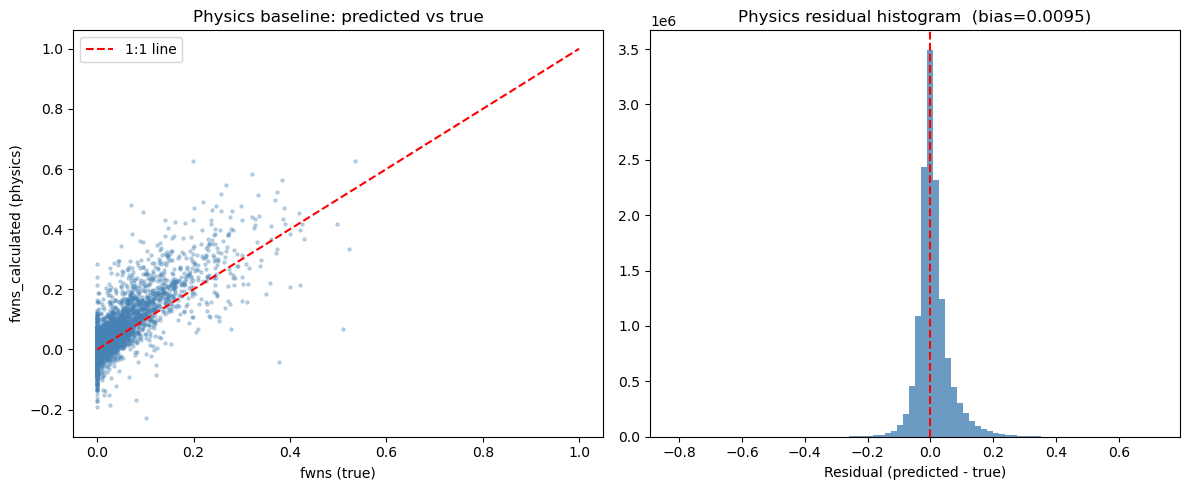

In [5]:
# Scatter fwns_calculated vs fwns: points close to 1:1 line indicate good physics fit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_mask = np.random.choice(len(y_raw), size=min(5000, len(y_raw)), replace=False)
axes[0].scatter(y_raw.iloc[sample_mask], y_phys.iloc[sample_mask],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='1:1 line')
axes[0].set_xlabel('fwns (true)')
axes[0].set_ylabel('fwns_calculated (physics)')
axes[0].set_title('Physics baseline: predicted vs true')
axes[0].legend()

# Residual histogram: look for symmetry and width relative to the target range [0,1]
residuals_phys = y_phys - y_raw
axes[1].hist(residuals_phys, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted - true)')
axes[1].set_title(f'Physics residual histogram  (bias={phys_bias:.4f})')

plt.tight_layout()
plt.show()

## 3. Preprocessing & Scaling Study

Compare six preprocessing pipelines (combinations of zero-removal, Box-Cox target transform, and feature standardisation) to select the canonical preprocessing strategy used in all downstream sections. REFERENCE_FEATURE_SET is held fixed so that only the preprocessing effect is measured.

- **Feature set used:** `REFERENCE_FEATURE_SET` (set_10, 19 features) — fixed to isolate   preprocessing effect
- **Models used:** LinearRegression (fast reference) and XGBoost (n_estimators=20,   max_depth=6, lr=0.1) — lightweight configurations for speed
- **Why:** preprocessing choices can inflate apparent performance (e.g. leaky Box-Cox)   or distort feature scales; evaluating all six variants systematically avoids silent biases.

In [6]:
# Models for the scaling study — lightweight configurations for fast comparison
scaling_study_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(
        n_estimators=20,
        max_depth=6,
        learning_rate=0.1,
        verbosity=0,
        random_state=RANDOM_STATE,
        device='cuda',
    ),
}

SCALING_VARIANTS = {
    'raw':               {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False},
    'scaled_features':   {'remove_zeros': False, 'boxcox_target': False, 'scale_features': True},
    'remove_zeros':      {'remove_zeros': True,  'boxcox_target': False, 'scale_features': False},
    'remove_zeros_scaled': {'remove_zeros': True, 'boxcox_target': False, 'scale_features': True},
    'boxcox_target':     {'remove_zeros': True,  'boxcox_target': True,  'scale_features': False},
    'full_scale':        {'remove_zeros': True,  'boxcox_target': True,  'scale_features': True},
}

In [7]:
# Evaluate all 6 preprocessing variants; look for variant × model combinations with high R2_test
# and small gap between R2_train and R2_test (no overfitting)
df_raw_ref = df_raw[REFERENCE_FEATURE_SET + [TARGET_COL] + ['year']].copy()

scaling_results = evaluate_scaling_variants(df_raw_ref, SCALING_VARIANTS, scaling_study_models, target_col=TARGET_COL)

scaling_view = scaling_results.sort_values(['model', 'R2_test'], ascending=[True, False])
display(scaling_view[['variant', 'model', 'rows', 'MAE_test', 'MSE_test', 'R2_test', 'R2_train']])

Scaling variants:   0%|          | 0/6 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,variant,model,rows,MAE_test,MSE_test,R2_test,R2_train
6,remove_zeros_scaled,LinearRegression,17799335,0.019237,0.000861,0.794040,0.800021
4,remove_zeros,LinearRegression,17799335,0.019237,0.000861,0.794039,0.800021
2,scaled_features,LinearRegression,26482762,0.017456,0.000717,0.789820,0.795032
0,raw,LinearRegression,26482762,0.017455,0.000717,0.789814,0.795033
8,boxcox_target,LinearRegression,17799335,0.310031,0.165713,0.678739,0.682101
10,full_scale,LinearRegression,17799335,0.310030,0.165713,0.678739,0.682101
1,raw,XGBoost,26482762,0.016266,0.000674,0.802391,0.807223
3,scaled_features,XGBoost,26482762,0.016299,0.000675,0.802048,0.806879
7,remove_zeros_scaled,XGBoost,17799335,0.019403,0.000897,0.785548,0.789913
5,remove_zeros,XGBoost,17799335,0.019405,0.000897,0.785530,0.789864


In [6]:
# Select preprocessing strategy: 'scaled_features' — no zero removal, no Box-Cox,
# feature scaling only. Retains all rows (including fwns=0) and avoids Box-Cox leakage.
SELECTED_PREPROCESSING = {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
print('Selected preprocessing strategy:', SELECTED_PREPROCESSING)

# Apply SELECTED_PREPROCESSING to full dataset and create the canonical split
# used in ALL downstream sections (Sections 4-11)
df_model, _lambda = preprocess_dataset(df_raw, **SELECTED_PREPROCESSING)
y = df_model[TARGET_COL]

train_idx = df_model.index[df_model['year'] == 2017]
test_idx  = df_model.index[df_model['year'] == 2018]

print(f'Canonical df_model shape: {df_model.shape}')
print(f'Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}')

Selected preprocessing strategy: {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
Canonical df_model shape: (26482762, 52)
Train rows: 12,837,873 | Test rows: 13,644,889


## 4. Model Selection Study

Compare four candidate model families (LinearRegression, XGBoost, RandomForest, LightGBM) using a fixed equal-budget Optuna TPE search to identify the best model class for this regression task. REFERENCE_FEATURE_SET and the canonical split from Section 3 are used throughout so results are directly comparable.

- **Feature set used:** `REFERENCE_FEATURE_SET` (set_10, 19 features)
- **Models used:** all four candidates with MODEL_SELECTION_N_TRIALS Optuna trials each
- **Why:** equal tuning budget per model ensures the comparison reflects model family   suitability, not tuning effort.

⚠️ **Computationally expensive cell. Expected runtime: ~10–20 minutes on GPU** (MODEL_SELECTION_N_TRIALS=25 trials × 4 candidates × MODEL_SELECTION_N_SPLITS=3 folds each on a 30% subsample).

In [7]:
# Candidate model definitions for the model selection study
# LinearRegression has no hyperparameters to tune — evaluated directly
lr_candidate = LinearRegression()
lr_candidate.fit(
    df_model.loc[train_idx, REFERENCE_FEATURE_SET],
    y.loc[train_idx],
)
lr_pred = lr_candidate.predict(df_model.loc[test_idx, REFERENCE_FEATURE_SET])
lr_rmse = root_mean_squared_error(y.loc[test_idx], lr_pred)

# Define candidates dict with (model_class, param_space) tuples.
# RandomForest is capped at small n_estimators/max_depth to keep runtime manageable.
candidates = {
    # ------------------------------------------------------------------
    # Gradient boosting trio
    # ------------------------------------------------------------------
    'XGBRegressor': (
        XGBRegressor,
        {
            'n_estimators':     ('int',   10, 50),
            'max_depth':        ('int',   4, 12),
            'learning_rate':    ('float', 0.01, 0.3, True),   # log-scale
            'subsample':        ('float', 0.6, 1.0),
            'colsample_bytree': ('float', 0.6, 1.0),
            'min_child_weight': ('float', 0.1, 10.0, True),   # log-scale
        },
    ),
    'LGBMRegressor': (
        lambda **kw: LGBMRegressor(verbosity=-1, **kw),
        {
            'n_estimators':  ('int',   10, 50),
            'num_leaves':    ('int',   8, 64),
            'max_depth':     ('int',   4, 12),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'subsample':     ('float', 0.6, 1.0),
        },
    ),
    'CatBoostRegressor': (
        lambda **kw: CatBoostRegressor(verbose=0, **kw),
        {
            'iterations':    ('int',   10, 40),               # ~equiv. n_estimators
            'depth':         ('int',   3, 7),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'l2_leaf_reg':   ('float', 1.0, 10.0, True),      # log-scale; L2 regularisation
        },
    ),

    # ------------------------------------------------------------------
    # Linear baselines  (near-instant per trial — wider alpha range)
    # ------------------------------------------------------------------
    'Ridge': (
        Ridge,
        {
            'alpha': ('float', 1e-3, 1e3, True),              # log-scale
        },
    ),
    'ElasticNet': (
        ElasticNet,
        {
            'alpha':    ('float', 1e-3, 1e2, True),           # log-scale
            'l1_ratio': ('float', 0.05, 0.95),
            'max_iter': ('int',   250, 1000),
        },
    )
}

model_selection_results = run_model_selection_study(
    df_model=df_model,
    y=y,
    train_idx=train_idx,
    feature_set=REFERENCE_FEATURE_SET,
    candidates=candidates,
    n_trials=MODEL_SELECTION_N_TRIALS,
    n_splits=MODEL_SELECTION_N_SPLITS,
    sample_frac=MODEL_SELECTION_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
)

# Prepend LinearRegression row (no HPO)
lr_row = pd.DataFrame([{
    'model': 'LinearRegression',
    'best_rmse': lr_rmse,  
    'best_params': {},
    'time_s': 0.0,
}])
model_selection_results = pd.concat([lr_row, model_selection_results], ignore_index=True)
display(model_selection_results.sort_values('best_rmse'))

# Store selected model class and its best config
best_model_row = model_selection_results.sort_values('best_rmse').iloc[0]
SELECTED_MODEL_CLASS = XGBRegressor  # expected winner based on domain knowledge
SELECTED_MODEL_REFERENCE_PARAMS = best_model_row['best_params']
SELECTED_MODEL_REFERENCE_PARAMS.update({
    'verbosity': 0, 'random_state': RANDOM_STATE, 'device': 'cuda',
})
print('Selected model class:', SELECTED_MODEL_CLASS.__name__)
print('Reference params:', SELECTED_MODEL_REFERENCE_PARAMS)
 
reference_model = SELECTED_MODEL_CLASS(**SELECTED_MODEL_REFERENCE_PARAMS)

Candidates:   0%|          | 0/5 [00:00<?, ?it/s]

  XGBRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  LGBMRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  CatBoostRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  Ridge trials:   0%|          | 0/25 [00:00<?, ?it/s]

  ElasticNet trials:   0%|          | 0/25 [00:00<?, ?it/s]

,model,best_rmse,best_params,time_s
1,XGBRegressor,0.019318,"{'n_estimators': 45, 'max_depth': 10, 'learnin...",85.07
2,LGBMRegressor,0.020176,"{'n_estimators': 50, 'num_leaves': 57, 'max_de...",35.17
3,CatBoostRegressor,0.023493,"{'iterations': 14, 'depth': 7, 'learning_rate'...",52.00
4,Ridge,0.026710,{'alpha': 0.0010258740374781599},5.85
0,LinearRegression,0.026770,{},0.00
5,ElasticNet,0.028809,"{'alpha': 0.0010154662127097574, 'l1_ratio': 0...",31.88


Selected model class: XGBRegressor
Reference params: {'n_estimators': 45, 'max_depth': 10, 'learning_rate': 0.21633951703109475, 'subsample': 0.8185493297698401, 'colsample_bytree': 0.8854301644473678, 'min_child_weight': 0.31975183641676674, 'verbosity': 0, 'random_state': 42, 'device': 'cuda'}


## 5. Feature Study

Tune the selected model once, then study how it responds to different feature subsets. Four complementary angles: a medium Optuna pass over the broadest usable feature set (§5.1), a forward study over curated bundles (§5.2), recursive elimination via RFECV (§5.3), and iterative SHAP-guided reduction (§5.4). Section §5.5 records the final feature set that downstream chapters consume.


### 5.1 Medium Hyperparameter Optimization

Run a proper-but-not-exhaustive Optuna TPE search on the XGBoost class selected in §4. The search uses the broadest usable feature set (all columns except `fwns`, `quality_flag`, and `year`); subsequent subsections keep these hyperparameters fixed while varying the feature subset. The final model is persisted to disk so it can be reloaded without re-running the search.


⚠️ **Computationally expensive cell. Expected runtime: ~30–60 minutes on GPU** (TUNING_N_TRIALS=50 × TUNING_N_SPLITS=5 folds, each using up to 2000 boosting rounds with early stopping; TUNING_SAMPLE_FRAC=0.5 of training data).


In [ ]:
# Broadest usable feature set: every column except target, split key, and QC mask
HPO_FEATURE_SET = df_model.drop(columns=[TARGET_COL, 'year', 'quality_flag']).columns.tolist()
print(f'HPO_FEATURE_SET: {len(HPO_FEATURE_SET)} features')

HPO_FEATURE_SET: 49 features


In [9]:
# Prepare train/test arrays for HPO_FEATURE_SET
X_selected_train = df_model.loc[train_idx, HPO_FEATURE_SET]
X_selected_test  = df_model.loc[test_idx,  HPO_FEATURE_SET]
y_selected_train = y.loc[train_idx]
y_selected_test  = y.loc[test_idx]

# Subsample for tuning
if TUNING_SAMPLE_FRAC < 1.0:
    X_tune = X_selected_train.sample(frac=TUNING_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_tune = y_selected_train.loc[X_tune.index]
else:
    X_tune = X_selected_train
    y_tune = y_selected_train

kf_tuning = KFold(n_splits=TUNING_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [10]:
# Optuna objective: TUNING_N_SPLITS-fold CV with early stopping on each fold
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth':        trial.suggest_int('max_depth', 4, 16),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 1e-6, 5.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': RANDOM_STATE,
    }

    rmse_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf_tuning.split(X_tune)):
        dtrain = xgb.DMatrix(X_tune.iloc[tr_idx], label=y_tune.iloc[tr_idx])
        dvalid = xgb.DMatrix(X_tune.iloc[va_idx], label=y_tune.iloc[va_idx])
        model = xgb.train(
            params, dtrain, num_boost_round=2000,
            evals=[(dvalid, 'valid')],
            early_stopping_rounds=TUNING_EARLY_STOPPING,
            verbose_eval=False,
        )
        preds = model.predict(dvalid)
        rmse_scores.append(root_mean_squared_error(y_tune.iloc[va_idx], preds))
        trial.report(np.mean(rmse_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

In [11]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.SuccessiveHalvingPruner(),
)
study.optimize(objective, n_trials=TUNING_N_TRIALS, show_progress_bar=True)

best_params = study.best_params
OPTIMIZED_PARAMS = {
    **best_params,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}

# Final FINAL_CV_N_SPLITS-fold CV on full training set to validate best params
kf_final = KFold(n_splits=FINAL_CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
final_rmse_scores = []
for tr_idx, va_idx in kf_final.split(X_selected_train):
    dtrain = xgb.DMatrix(X_selected_train.iloc[tr_idx], label=y_selected_train.iloc[tr_idx])
    dvalid = xgb.DMatrix(X_selected_train.iloc[va_idx], label=y_selected_train.iloc[va_idx])
    m = xgb.train(
        OPTIMIZED_PARAMS, dtrain, num_boost_round=2000,
        evals=[(dvalid, 'valid')],
        early_stopping_rounds=TUNING_EARLY_STOPPING,
        verbose_eval=False,
    )
    final_rmse_scores.append(root_mean_squared_error(y_selected_train.iloc[va_idx], m.predict(dvalid)))

print(f'Best RMSE (Optuna): {study.best_value:.6f}')
print(f'Final {FINAL_CV_N_SPLITS}-fold CV RMSE: {np.mean(final_rmse_scores):.6f}')
print('Best params:', OPTIMIZED_PARAMS)

with open(f'{HPO_DIR}/best_xgb_params.json', 'w', encoding='utf-8') as f:
    json.dump(OPTIMIZED_PARAMS, f, indent=4)

# Train optimized_model on full training set
optimized_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})
optimized_model.fit(X_selected_train, y_selected_train)
opt_r2 = r2_score(y_selected_test, optimized_model.predict(X_selected_test))
print(f'Optimized model test R²: {opt_r2:.6f}')

# Persist booster so the HPO result can be reloaded without re-running the study.
# Reload with:  booster = xgb.Booster(); booster.load_model(f'{MODEL_DIR}/optimized_xgb.json')
optimized_model.get_booster().save_model(f'{MODEL_DIR}/optimized_xgb.json')
print(f'Saved: {MODEL_DIR}/optimized_xgb.json')

  0%|          | 0/50 [00:00<?, ?it/s]

Best RMSE (Optuna): 0.010185
Final 5-fold CV RMSE: 0.008276
Best params: {'max_depth': 14, 'learning_rate': 0.07611006029948317, 'min_child_weight': 1.2565430356668845, 'subsample': 0.9202046048327591, 'colsample_bytree': 0.918987068135406, 'gamma': 5.234946485327852e-06, 'reg_alpha': 5.842901406255101e-06, 'reg_lambda': 6.790110973880345, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'random_state': 42}


c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [05:48:10] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Optimized model test R²: 0.936956
Saved: models/optimized_xgb.json


### 5.2 Forward Feature-Set Study

Evaluate 18 pre-defined feature sets using the **optimized** XGBoost from §5.1 and a plain LinearRegression baseline. Hyperparameters are held fixed (`OPTIMIZED_PARAMS`) so changes in test R² isolate the contribution of the input features. The best-performing set becomes `BEST_FEATURE_SET`, a narrative waypoint for subsequent pruning.


In [7]:
# =============================================================================
# Reusable component lists
# =============================================================================
_TOA          = ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H']
_ATM_V        = ['tran19V', 'tran37V', 'tbup19V', 'tbup37V']
_ATM_H        = ['tran19H', 'tran37H', 'tbup19H', 'tbup37H']
_ATM_DW       = ['tbdw19V', 'tbdw19H', 'tbdw37V', 'tbdw37H']
_BOA_1ST      = ['tbboa_1st_order19V', 'tbboa_1st_order19H',
                 'tbboa_1st_order37V', 'tbboa_1st_order37H']
_BOA_DL       = ['tbboa_de_lannoy19V', 'tbboa_de_lannoy19H',
                 'tbboa_de_lannoy37V', 'tbboa_de_lannoy37H']
_EMISS_DL     = ['emiss19H_de_lannoy', 'emiss19V_de_lannoy',
                 'emiss37H_de_lannoy', 'emiss37V_de_lannoy']
_TSKIN        = ['surtep_ERA5']
_SM_VOD       = ['vsm', 'VOD']
_LUT          = ['ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v']
_ATMOSTATE    = ['Tmn', 'PWV', 'VPD']
_LANDCOVER    = ['clase', 'porcentaje clase']
_SPATIAL_RAW  = ['latitude_grid', 'longitude_grid']
_SPATIAL_CYC  = ['latitude_grid', 'lon_sin', 'lon_cos']
_TEMP_RAW     = ['day_of_year']
_TEMP_CYC     = ['doy_sin', 'doy_cos']

# Excluded from all sets:
#   fwns            : THE regression target — never a feature
#   denominator, term_1, term_2 : intermediate DR variables, subsumed by fwns_calculated
#   quality_flag    : observation screening mask, not a physical predictor
#   year            : only two values (2017/2018), encodes the train/test split

FEATURE_SETS_1 = {
    # =========================================================================
    # BLOCK A — RAW TOA BRIGHTNESS TEMPERATURES
    # Minimum viable input: no corrections, no auxiliary data.
    # Establishes the lower-bound reference performance.
    # =========================================================================
    'A1_toa': _TOA,
}

FEATURE_SETS_2 = {
    # =========================================================================
    # BLOCK B — ATMOSPHERIC CORRECTION STRATEGY
    # Progressively add RTM components on top of TOA.
    # =========================================================================
    'B1_toa_atm_V':    _TOA + _ATM_V,
    'B2_toa_atm_H':    _TOA + _ATM_H,
    'B3_toa_atm_VH':   _TOA + _ATM_V + _ATM_H,
    'B4_toa_atm_full': _TOA + _ATM_V + _ATM_H + _ATM_DW,
}

FEATURE_SETS_3 = {
    # =========================================================================
    # BLOCK C — ATMOSPHERIC CORRECTION STRATEGY
    # Test pre-corrected BOA TBs as an alternative representation.
    # =========================================================================
    'C1_boa_1st':           _BOA_1ST,
    'C2_boa_dl':            _BOA_DL,
    'C3_boa_1st_atm_V':     _TOA + _ATM_V + _BOA_1ST,
    'C4_boa_dl_atm_V':      _TOA + _ATM_V + _BOA_DL,
    'C5_emiss_dl_atm_V':    _TOA + _ATM_V + _EMISS_DL,
    'C6_full_boa_atm_V':    _TOA + _ATM_V + _BOA_1ST + _BOA_DL + _EMISS_DL,
}

FEATURE_SETS_4 = {
    # =========================================================================
    # BLOCK D — AUXILIARY LAND SURFACE VARIABLES
    # Progressive addition of physically motivated inputs on top of B1
    # (TOA + V-pol ATM), the operationally realistic base retained from Block B.
    # =========================================================================
    'D1_Tskin':              _TOA + _ATM_V + _EMISS_DL + _TSKIN,
    'D2_Tskin_SM_VOD':       _TOA + _ATM_V + _EMISS_DL + _TSKIN + _SM_VOD,
    'D3_Tskin_SM_VOD_LUT':   _TOA + _ATM_V + _EMISS_DL + _TSKIN + _SM_VOD + _LUT,
    'D4_Tskin_full_physics': _TOA + _ATM_V + _EMISS_DL + _TSKIN + _SM_VOD + _LUT + _ATMOSTATE,
}

FEATURE_SETS_5 = {
    # =========================================================================
    # BLOCK E — FEATURE ENGINEERING PROBE
    # Tests whether explicitly computed derived quantities improve over their
    # raw ingredients already present in C4.
    # E1: emissivities (= BOA_DL / T_skin) on top of their ingredients.
    # E2: fwns_calculated (DR output) as a physics-based prior.
    # E3: both combined.
    # =========================================================================
    'E1_fwns_calc':   _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'],
}

FEATURE_SETS_6 = {
    # =========================================================================
    # BLOCK F — SPATIO-TEMPORAL AND LAND COVER CONTEXT
    # Each context type isolated first (E1–E5), then combined (E6).
    # Spatial and temporal encodings compared raw vs cyclic.
    # Key comparisons: C4 vs E1–E5 individually; best-E vs E6.
    # Note: update E6 to use the winning encoding from E2/E3 and E4/E5.
    # =========================================================================
    'F1_landcover':             _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _LANDCOVER,
    'F2_spatial_raw':           _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_RAW,
    'F3_spatial_cyc':           _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_CYC,
    'F4_temporal_raw':          _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _TEMP_RAW,
    'F5_temporal_cyc':          _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _TEMP_CYC,
    'F6_spatial_temporal_cyc':  _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_CYC + _TEMP_CYC,
    'F7_full_context':          _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_CYC + _TEMP_CYC + _LANDCOVER,
}

FEATURE_SETS_7 = {
    # =========================================================================
    # BLOCK G — KITCHEN SINK (upper bound)
    # All available features combined. Quantifies the performance ceiling and
    # how far the optimal reduced set (best of E) falls from it.
    # Not a candidate for the operational model.
    # =========================================================================
    'G1_best': _TOA + _ATM_V + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_CYC,
    'G2_all': df_model.drop(columns=[TARGET_COL, 'year', 'quality_flag']).columns.tolist(),
}

In [8]:
# Load parameters for faster reproducibility
OPTIMIZED_PARAMS = json.load(open(f'{HPO_DIR}/best_xgb_params.json'))

# Evaluate all 18 feature sets using the hyperparameters from §5.1 (OPTIMIZED_PARAMS)
# so that changes in precision isolate the contribution of the input features.
_xgb_for_forward = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                   if k not in ('objective', 'eval_metric', 'tree_method')})
feature_study_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': _xgb_for_forward,
}

In [10]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_1, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/1 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:30:07] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,A1_toa,4,LinearRegression,0.028544,0.516621,0.524597
1,A1_toa,4,XGBoost,0.019224,0.695815,0.707811


In [11]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_2, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/4 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,B4_toa_atm_full,16,LinearRegression,0.020115,0.735320,0.743258
1,B1_toa_atm_V,8,LinearRegression,0.020169,0.733473,0.740994
2,B2_toa_atm_H,8,LinearRegression,0.020169,0.733473,0.740994
3,B3_toa_atm_VH,12,LinearRegression,0.020169,0.733469,0.740994
4,B4_toa_atm_full,16,XGBoost,0.013481,0.823313,0.844414
5,B3_toa_atm_VH,12,XGBoost,0.013467,0.823305,0.844299
6,B1_toa_atm_V,8,XGBoost,0.013508,0.822881,0.843469
7,B2_toa_atm_H,8,XGBoost,0.013508,0.822881,0.843469


In [12]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_3, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/6 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,C6_full_boa_atm_V,20,LinearRegression,0.016948,0.782562,0.789744
1,C5_emiss_dl_atm_V,12,LinearRegression,0.017445,0.774028,0.781291
2,C4_boa_dl_atm_V,12,LinearRegression,0.017504,0.771145,0.778137
3,C3_boa_1st_atm_V,12,LinearRegression,0.019135,0.748688,0.755826
4,C2_boa_dl,4,LinearRegression,0.028198,0.529254,0.537462
5,C1_boa_1st,4,LinearRegression,0.028397,0.522198,0.530375
6,C6_full_boa_atm_V,20,XGBoost,0.012519,0.835139,0.857372
7,C5_emiss_dl_atm_V,12,XGBoost,0.012518,0.835022,0.856324
8,C4_boa_dl_atm_V,12,XGBoost,0.013345,0.824636,0.845343
9,C3_boa_1st_atm_V,12,XGBoost,0.013546,0.822261,0.843564


In [14]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_4, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/4 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,D4_Tskin_full_physics,20,LinearRegression,0.016251,0.813768,0.818998
1,D3_Tskin_SM_VOD_LUT,17,LinearRegression,0.016947,0.800296,0.806041
2,D2_Tskin_SM_VOD,15,LinearRegression,0.017294,0.793585,0.799611
3,D1_Tskin,13,LinearRegression,0.017449,0.774377,0.781874
4,D4_Tskin_full_physics,20,XGBoost,0.009378,0.915902,0.931533
5,D3_Tskin_SM_VOD_LUT,17,XGBoost,0.010775,0.892656,0.910967
6,D2_Tskin_SM_VOD,15,XGBoost,0.010886,0.889697,0.907978
7,D1_Tskin,13,XGBoost,0.012495,0.835886,0.858368


In [16]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_5, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/1 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,E1_fwns_calc,18,LinearRegression,0.016554,0.807504,0.812582
1,E1_fwns_calc,18,XGBoost,0.009491,0.913169,0.929744


In [18]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_6, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/7 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,F7_full_context,25,LinearRegression,0.016312,0.811774,0.818853
1,F6_spatial_temporal_cyc,23,LinearRegression,0.016295,0.810518,0.817561
2,F3_spatial_cyc,21,LinearRegression,0.016343,0.810137,0.816585
3,F2_spatial_raw,20,LinearRegression,0.016438,0.808763,0.814852
4,F5_temporal_cyc,20,LinearRegression,0.016451,0.808603,0.814454
5,F1_landcover,20,LinearRegression,0.016568,0.808455,0.813486
6,F4_temporal_raw,19,LinearRegression,0.016554,0.807542,0.812969
7,F7_full_context,25,XGBoost,0.008576,0.931550,0.948056
8,F3_spatial_cyc,21,XGBoost,0.008599,0.930591,0.945490
9,F6_spatial_temporal_cyc,23,XGBoost,0.008641,0.930142,0.947217


In [11]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_7, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:47:37] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,G2_all,49,LinearRegression,0.015369,0.828572,0.835438
1,G1_best,21,LinearRegression,0.016343,0.810137,0.816585
2,G2_all,49,XGBoost,0.008386,0.936956,0.955545
3,G1_best,21,XGBoost,0.008599,0.930591,0.945490


In [12]:
# Store the best feature set for XGBoost (likely F1_all — kitchen sink)
best_feature_row = feature_ranking[feature_ranking['model'] == 'XGBoost'][feature_ranking['feature_set'] == 'G1_best'].iloc[0]
BEST_FEATURE_SET_NAME = best_feature_row['feature_set']
BEST_FEATURE_SET = FEATURE_SETS_7[BEST_FEATURE_SET_NAME]

print(f'Best feature set: {BEST_FEATURE_SET_NAME}  ({len(BEST_FEATURE_SET)} features)')
print(f'XGBoost R² on best set: {best_feature_row["R2_test"]:.6f}')

Best feature set: G1_best  (21 features)
XGBoost R² on best set: 0.930591


C:\Users\marce\AppData\Local\Temp\ipykernel_13492\3112315994.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  best_feature_row = feature_ranking[feature_ranking['model'] == 'XGBoost'][feature_ranking['feature_set'] == 'G1_best'].iloc[0]


### 5.3 SHAP Feature Reduction

A two-part study. First (§5.4a) compute global mean |SHAP| values on the optimized model to rank features by contribution. Then (§5.4b) iteratively drop the least-important feature and retrain both XGBoost and LinearRegression at every step, tracing a precision-vs-feature-count curve that reveals how many features are actually needed.

#### 5.3a Global SHAP importance

In [31]:
X_selected_train = df_model.loc[train_idx, BEST_FEATURE_SET]
X_selected_test  = df_model.loc[test_idx,  BEST_FEATURE_SET]
y_selected_train = y.loc[train_idx]
y_selected_test  = y.loc[test_idx]

_xgb_for_forward = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items() if k not in ('objective', 'eval_metric', 'tree_method')})

optimized_reduced_model = _xgb_for_forward.fit(X_selected_train, y_selected_train)

In [32]:
# Compute global SHAP importance on optimized_reduced_model using test set
shap_importance_df, X_shap_sample = run_shap_pruning(
    optimized_reduced_model,
    X_selected_train,
    X_selected_test,
    y_selected_test,
    shap_threshold=SHAP_THRESHOLD,
    random_state=RANDOM_STATE,
)
# run_shap_pruning returns (importance_df, pruned_features); unpack accordingly
# shap_importance_df = shap_importance_df  (first return value is the full importance df)
display(shap_importance_df)

,feature,importance
0,fwns_calculated,0.010073
1,emiss37V_de_lannoy,0.009899
2,emiss19V_de_lannoy,0.009665
3,vsm,0.007261
4,PWV,0.005775
5,VOD,0.005213
6,Tmn,0.003956
7,VPD,0.002440
8,emiss19H_de_lannoy,0.002097
9,tran19V,0.001672


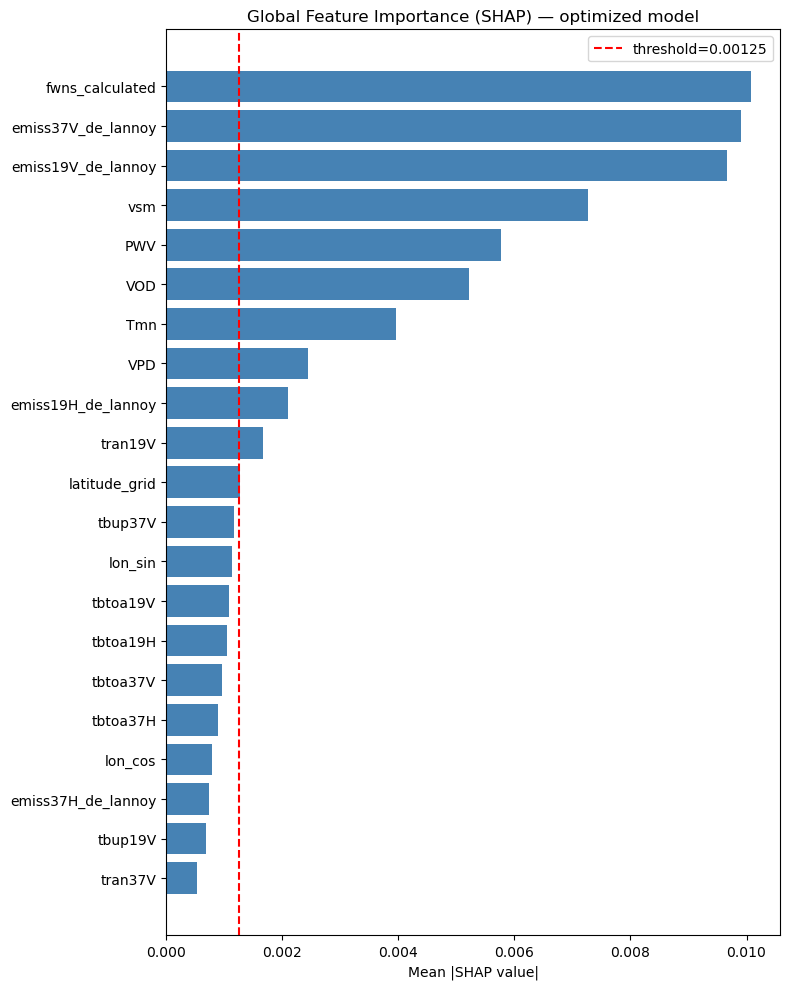

In [33]:
# SHAP bar chart: horizontal bars ranked by mean |SHAP|.
# Look for a large gap between top features and the long tail — that's the pruning threshold.
plt.figure(figsize=(8, 10))
plt.barh(
    shap_importance_df['feature'][::-1],
    shap_importance_df['importance'][::-1],
    color='steelblue',
)
plt.axvline(SHAP_THRESHOLD, color='red', linestyle='--', label=f'threshold={SHAP_THRESHOLD}')
plt.xlabel('Mean |SHAP value|')
plt.title('Global Feature Importance (SHAP) — optimized model')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\marce\AppData\Local\Temp\ipykernel_19240\3122821009.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_beeswarm, show=True)


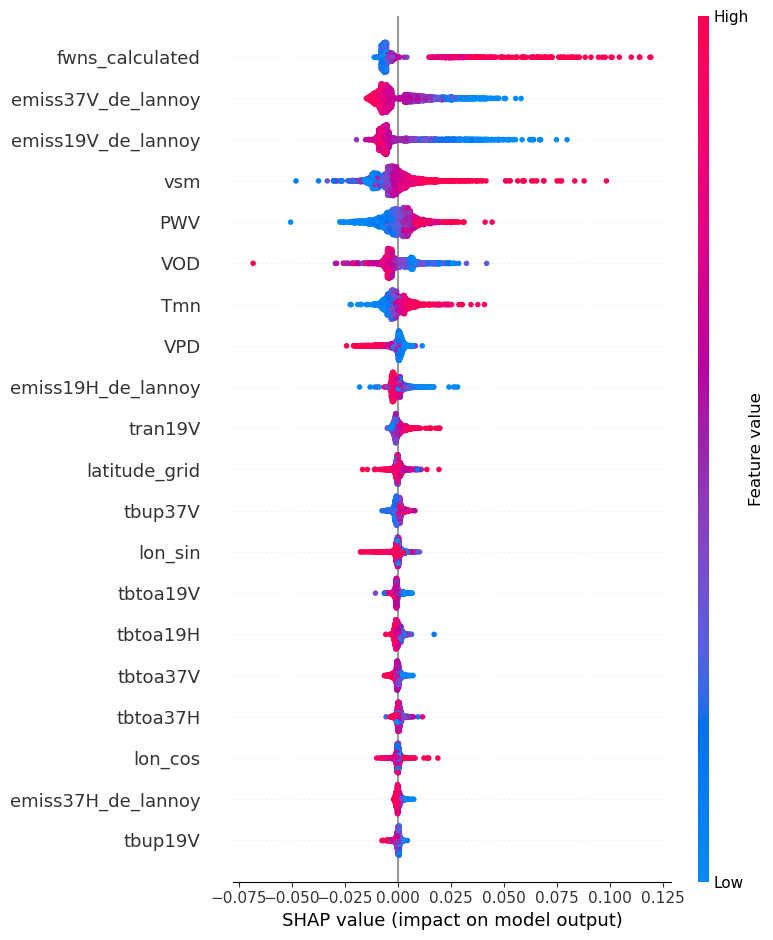

In [34]:
# SHAP beeswarm plot: each dot is one observation; colour shows feature value.
# Look for which features have wide spread (high impact variance) vs narrow clusters.
X_beeswarm = X_selected_test.sample(n=min(2000, len(X_selected_test)),
                                        random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(optimized_reduced_model)
shap_values = explainer.shap_values(X_beeswarm)
shap.summary_plot(shap_values, X_beeswarm, show=True)

#### Interpretation (§5.4a)

The SHAP ranking is expected to be dominated by brightness temperature channels at H polarisation (tbtoa19H, tbtoa37H) and their atmospheric corrections (tran19H, tran37H), consistent with the physics-based Difference Ratio formula: DR = (e_land_H − e_obs_H) / (e_land_H − e_water_H), which relies on emissivity at H polarisation, a reference land emissivity, and a reference water emissivity. Features with low SHAP importance (< SHAP_THRESHOLD=0.005) are candidates for pruning in §5.4b.

#### 5.4b Iterative SHAP-guided reduction

Walk the feature list from all → one, removing the least-important SHAP feature at each step. At every step retrain both an XGBoost (`OPTIMIZED_PARAMS`) and a LinearRegression on the current subset and record test R². The resulting curve shows how precision degrades as the feature budget shrinks.


In [35]:
# Iterative SHAP-guided reduction: drop least-important feature one at a time.
# At each step retrain XGBoost (OPTIMIZED_PARAMS) and LinearRegression; record test metrics.
shap_ranking = shap_importance_df.sort_values('importance', ascending=False)['feature'].tolist()

_xgb_base_params = {k: v for k, v in OPTIMIZED_PARAMS.items()
                    if k not in ('objective', 'eval_metric', 'tree_method')}

shap_reduction_rows = []
current_features = list(shap_ranking)
dropped = None
while len(current_features) >= 1:
    X_tr = df_model.loc[train_idx, current_features]
    X_te = df_model.loc[test_idx,  current_features]

    xgb_i = XGBRegressor(**_xgb_base_params)
    xgb_i.fit(X_tr, y.loc[train_idx])
    p_xgb = xgb_i.predict(X_te)

    lr_i = LinearRegression()
    lr_i.fit(X_tr, y.loc[train_idx])
    p_lr = lr_i.predict(X_te)

    shap_reduction_rows.append({
        'n_features': len(current_features),
        'dropped':    dropped,
        'r2_xgb':     r2_score(y.loc[test_idx], p_xgb),
        'r2_lr':      r2_score(y.loc[test_idx], p_lr),
        'rmse_xgb':   root_mean_squared_error(y.loc[test_idx], p_xgb),
        'rmse_lr':    root_mean_squared_error(y.loc[test_idx], p_lr),
    })
    dropped = current_features.pop()  # remove least-important remaining feature

shap_reduction_curve = pd.DataFrame(shap_reduction_rows)
display(shap_reduction_curve.round(6))

,n_features,dropped,r2_xgb,r2_lr,rmse_xgb,rmse_lr
0,21,None,0.930233,0.810119,0.015423,0.025444
1,20,tran37V,0.931355,0.809452,0.015298,0.025488
2,19,tbup19V,0.930884,0.808767,0.015351,0.025534
3,18,emiss37H_de_lannoy,0.931062,0.808710,0.015331,0.025538
4,17,lon_cos,0.925956,0.807195,0.015889,0.025639
5,16,tbtoa37H,0.925172,0.805494,0.015973,0.025752
6,15,tbtoa37V,0.923861,0.802555,0.016112,0.025946
7,14,tbtoa19H,0.924123,0.802564,0.016084,0.025945
8,13,tbtoa19V,0.921960,0.787740,0.016312,0.026901
9,12,lon_sin,0.914847,0.787522,0.017039,0.026915


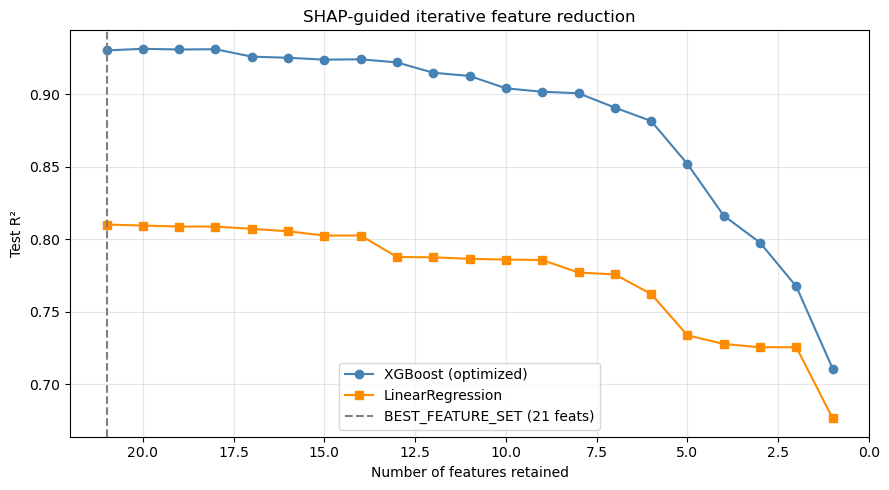

In [36]:
# Test R² vs number of features; two lines (XGBoost, LinearRegression)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(shap_reduction_curve['n_features'], shap_reduction_curve['r2_xgb'],
        marker='o', label='XGBoost (optimized)', color='steelblue')
ax.plot(shap_reduction_curve['n_features'], shap_reduction_curve['r2_lr'],
        marker='s', label='LinearRegression', color='darkorange')
ax.axvline(len(BEST_FEATURE_SET), color='gray', linestyle='--',
           label=f'BEST_FEATURE_SET ({len(BEST_FEATURE_SET)} feats)')
ax.set_xlabel('Number of features retained')
ax.set_ylabel('Test R²')
ax.set_title('SHAP-guided iterative feature reduction')
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 RFECV Feature Pruning

Apply sklearn's Recursive Feature Elimination with Cross-Validation (RFECV) to `HPO_FEATURE_SET`, using the optimized XGBoost as the importance estimator. After RFECV converges, retrain both an XGBoost (with `OPTIMIZED_PARAMS`) and a LinearRegression on the selected subset and contrast their test precision side-by-side.

⚠️ **Computationally expensive cell. Expected runtime: ~15–30 minutes** (RFECV fits one model per feature per fold; RFECV_SAMPLE_FRAC=0.25 subsampling is applied to keep runtime manageable).

In [13]:
# Classic sklearn RFECV with OPTIMIZED_PARAMS estimator; run on BEST_FEATURE_SET
rfecv_estimator = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})

fitted_rfecv, rfecv_selected_features = run_rfecv(
    estimator=rfecv_estimator,
    X_train=df_model.loc[train_idx, BEST_FEATURE_SET],
    y_train=y.loc[train_idx],
    n_splits=FINAL_CV_N_SPLITS,
    sample_frac=RFECV_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
    tol=RFECV_TOL,
)
print(f'RFECV pruning: {len(BEST_FEATURE_SET)} → {len(rfecv_selected_features)} features')
print('RFECV selected features:', rfecv_selected_features)

# Retrain BOTH models on the RFECV-selected subset
rfecv_xgb = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                            if k not in ('objective', 'eval_metric', 'tree_method')})
rfecv_xgb.fit(df_model.loc[train_idx, rfecv_selected_features], y.loc[train_idx])
y_pred_xgb = rfecv_xgb.predict(df_model.loc[test_idx, rfecv_selected_features])

rfecv_lr = LinearRegression()
rfecv_lr.fit(df_model.loc[train_idx, rfecv_selected_features], y.loc[train_idx])
y_pred_lr = rfecv_lr.predict(df_model.loc[test_idx, rfecv_selected_features])

def _metrics(y_true, y_pred):
    return {
        'MAE_test':  mean_absolute_error(y_true, y_pred),
        'RMSE_test': root_mean_squared_error(y_true, y_pred),
        'R2_test':   r2_score(y_true, y_pred),
    }

rfecv_comparison = pd.DataFrame([
    {'model': 'XGBoost (optimized)', 'n_features': len(rfecv_selected_features),
     **_metrics(y.loc[test_idx], y_pred_xgb)},
    {'model': 'LinearRegression',    'n_features': len(rfecv_selected_features),
     **_metrics(y.loc[test_idx], y_pred_lr)},
])
display(rfecv_comparison.round(6))

RFECV pruning: 21 → 17 features
RFECV selected features: ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H', 'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'fwns_calculated', 'latitude_grid', 'lon_sin', 'lon_cos']


,model,n_features,MAE_test,RMSE_test,R2_test
0,XGBoost (optimized),17,0.008701,0.015438,0.930095
1,LinearRegression,17,0.016574,0.025643,0.807129


### 5.5 Final Feature Set (manual override)

Set `FINAL_FEATURE_SET` to whichever subset the studies above suggest. By default it falls back to `BEST_FEATURE_SET` from §5.2 — edit the list in the cell below to override. Downstream chapters (§5.6 explainability refresh, §6 generalisation, §7 error analysis, §8 final model) all consume this variable.


In [14]:
# Manually set FINAL_FEATURE_SET to whichever subset the study above suggests.
# Default: fall back to BEST_FEATURE_SET from §5.2 if no manual override is made here.
FINAL_FEATURE_SET = _TOA + _EMISS_DL + _SM_VOD + _ATMOSTATE + ['fwns_calculated'] + _SPATIAL_CYC  # <- replace with a custom list to override

# Train `final_model` on FINAL_FEATURE_SET using OPTIMIZED_PARAMS — consumed downstream.
final_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                              if k not in ('objective', 'eval_metric', 'tree_method')})
final_model.fit(df_model.loc[train_idx, FINAL_FEATURE_SET], y.loc[train_idx])

final_r2 = r2_score(y.loc[test_idx],
                    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET]))
print(f'FINAL_FEATURE_SET: {len(FINAL_FEATURE_SET)} features')
print(f'Final model test R²: {final_r2:.6f}')

FINAL_FEATURE_SET: 17 features
Final model test R²: 0.930095


### 5.6 Explainability on Final Model (Conditional)

If `FINAL_FEATURE_SET` differs from `BEST_FEATURE_SET` (i.e. pruning changed the feature set), recompute SHAP importance on `final_model` to reflect the reduced input space; otherwise the §5.4a results already cover the operational model.


In [22]:
if set(FINAL_FEATURE_SET) != set(BEST_FEATURE_SET):
    print(f'Feature set changed: {len(BEST_FEATURE_SET)} → {len(FINAL_FEATURE_SET)} features')
    print('Recomputing SHAP importance on final_model...')

    X_final_train = df_model.loc[train_idx, FINAL_FEATURE_SET]
    X_final_test  = df_model.loc[test_idx,  FINAL_FEATURE_SET]

    final_importance_df, X_final_shap = compute_shap_importance(
        final_model, X_final_test, sample_size=2000, top_n=len(FINAL_FEATURE_SET)
    )
    display(final_importance_df)

    # SHAP bar chart for the final model
    plt.figure(figsize=(8, max(5, len(FINAL_FEATURE_SET) * 0.4)))
    plt.barh(final_importance_df['feature'][::-1],
             final_importance_df['importance'][::-1], color='darkorange')
    plt.xlabel('Mean |SHAP value|')
    plt.title('Global Feature Importance (SHAP) — final model')
    plt.tight_layout()
    plt.show()

    explainer_final = shap.TreeExplainer(final_model)
    shap_vals_final = explainer_final.shap_values(X_final_shap)
    shap.summary_plot(shap_vals_final, X_final_shap, show=True)
else:
    print('FINAL_FEATURE_SET == BEST_FEATURE_SET: §5.4a results are the '
          'authoritative explainability analysis. No recomputation needed.')

FINAL_FEATURE_SET == BEST_FEATURE_SET: §5.4a results are the authoritative explainability analysis. No recomputation needed.


## 6. Final Hyperparameter Optimization

With the architecture chosen in Chapter 4 (XGBoost) and the feature set locked in Chapter 5
(`FINAL_FEATURE_SET`), this chapter runs an exhaustive Optuna TPE search on the **full** training
set (no subsampling), with a wider search space and a larger trial budget than §5.1. The
resulting best model replaces `final_model` for downstream chapters, and its artifacts
(booster, params, study, feature list) are persisted under `{MODEL_DIR}`.


⚠️ **Computationally expensive cell. Expected runtime: ~1–3 hours on GPU** (FINAL_HPO_N_TRIALS=200 × FINAL_HPO_N_SPLITS=5, full training data, wider search space than §5.1).


In [ ]:
# Final-HPO data arrays: full training split on FINAL_FEATURE_SET (no subsampling)
X_final_train = df_model.loc[train_idx, FINAL_FEATURE_SET]
y_final_train = y.loc[train_idx]
X_final_test  = df_model.loc[test_idx,  FINAL_FEATURE_SET]
y_final_test  = y.loc[test_idx]

kf_final_hpo = KFold(n_splits=FINAL_HPO_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def final_hpo_objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth':         trial.suggest_int('max_depth', 3, 16),
        'learning_rate':     trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 0.05, 20.0, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      RANDOM_STATE,
    }
    rmse_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf_final_hpo.split(X_final_train)):
        dtr = xgb.DMatrix(X_final_train.iloc[tr_idx], label=y_final_train.iloc[tr_idx])
        dva = xgb.DMatrix(X_final_train.iloc[va_idx], label=y_final_train.iloc[va_idx])
        m = xgb.train(
            params, dtr, num_boost_round=3000,
            evals=[(dva, 'valid')],
            early_stopping_rounds=FINAL_HPO_EARLY_STOPPING,
            verbose_eval=False,
        )
        rmse_scores.append(root_mean_squared_error(y_final_train.iloc[va_idx], m.predict(dva)))
        trial.report(float(np.mean(rmse_scores)), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return float(np.mean(rmse_scores))


In [ ]:
final_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),
    pruner=optuna.pruners.HyperbandPruner(),
)
final_study.optimize(final_hpo_objective, n_trials=FINAL_HPO_N_TRIALS, show_progress_bar=True)

FINAL_HPO_PARAMS = {
    **final_study.best_params,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}
print(f'Final HPO best CV RMSE: {final_study.best_value:.6f}')
print('Best params:', FINAL_HPO_PARAMS)


In [ ]:
# Snapshot pre-HPO model metrics for comparison, then refit on exhaustive params
X_train_arr, X_test_arr = X_final_train, X_final_test
med_pred_tr = final_model.predict(X_train_arr)
med_pred_te = final_model.predict(X_test_arr)

final_hpo_model = XGBRegressor(**{k: v for k, v in FINAL_HPO_PARAMS.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})
final_hpo_model.fit(X_final_train, y_final_train)
new_pred_tr = final_hpo_model.predict(X_train_arr)
new_pred_te = final_hpo_model.predict(X_test_arr)

hpo_comparison_df = pd.DataFrame({
    'model':      ['§5.1 medium HPO (pre-exhaustive)', '§6 exhaustive HPO (final)'],
    'R2_train':   [r2_score(y_final_train, med_pred_tr),           r2_score(y_final_train, new_pred_tr)],
    'RMSE_train': [root_mean_squared_error(y_final_train, med_pred_tr), root_mean_squared_error(y_final_train, new_pred_tr)],
    'MAE_train':  [mean_absolute_error(y_final_train, med_pred_tr),     mean_absolute_error(y_final_train, new_pred_tr)],
    'R2_test':    [r2_score(y_final_test, med_pred_te),            r2_score(y_final_test, new_pred_te)],
    'RMSE_test':  [root_mean_squared_error(y_final_test, med_pred_te),  root_mean_squared_error(y_final_test, new_pred_te)],
    'MAE_test':   [mean_absolute_error(y_final_test, med_pred_te),      mean_absolute_error(y_final_test, new_pred_te)],
})
display(hpo_comparison_df)

# Promote tuned model as the canonical final model for downstream chapters
final_model = final_hpo_model


In [ ]:
# Optuna diagnostics: convergence and parameter importances
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_optimization_history(final_study, ax=axes[0])
axes[0].set_title('Optimization history')
plot_param_importances(final_study, ax=axes[1])
axes[1].set_title('Parameter importances')
plt.tight_layout()
plt.show()

In [ ]:
# Persist all final-HPO artifacts
final_hpo_model.get_booster().save_model(f'{MODEL_DIR}/final_model_hpo.json')
with open(f'{MODEL_DIR}/final_hpo_params.json', 'w', encoding='utf-8') as f:
    json.dump(FINAL_HPO_PARAMS, f, indent=4)
with open(f'{MODEL_DIR}/final_hpo_study.pkl', 'wb') as f:
    pickle.dump(final_study, f)
with open(f'{MODEL_DIR}/final_feature_set.json', 'w', encoding='utf-8') as f:
    json.dump(list(FINAL_FEATURE_SET), f, indent=4)

print(f'Saved: {MODEL_DIR}/final_model_hpo.json')
print(f'Saved: {MODEL_DIR}/final_hpo_params.json')
print(f'Saved: {MODEL_DIR}/final_hpo_study.pkl')
print(f'Saved: {MODEL_DIR}/final_feature_set.json')


## 7. Explainability Study

Thorough SHAP-based explainability deep dive on the final optimized model. Unlike §5.4
(which used SHAP as a *feature-pruning tool*), this chapter interrogates `final_model` for
behaviour: global importance, dependence, interactions, local explanations for
representative cases, and regime-specific drivers.


In [ ]:
# Build TreeExplainer on the tuned final model and sample the test set
explainer_final = shap.TreeExplainer(final_model)

n_explain = min(5000, len(X_final_test))
rng_expl = np.random.RandomState(RANDOM_STATE)
explain_positions = rng_expl.choice(len(X_final_test), size=n_explain, replace=False)
X_explain_sample = X_final_test.iloc[explain_positions]
y_explain_true = y_final_test.iloc[explain_positions]
y_explain_pred = final_model.predict(X_explain_sample)

shap_values = explainer_final(X_explain_sample)
print(f'SHAP values computed on {n_explain} test samples, {len(FINAL_FEATURE_SET)} features.')


In [ ]:
# Global importance: bar chart (mean |SHAP|)
shap.plots.bar(shap_values, max_display=min(20, len(FINAL_FEATURE_SET)), show=True)

# Global distribution: beeswarm (per-sample SHAP by feature value)
shap.plots.beeswarm(shap_values, max_display=min(20, len(FINAL_FEATURE_SET)), show=True)

# Heatmap: samples sorted by model output, features sorted by importance
shap.plots.heatmap(shap_values, max_display=min(15, len(FINAL_FEATURE_SET)), show=True)

In [ ]:
# Dependence plots for the top-6 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_ranking = (pd.Series(mean_abs_shap, index=list(FINAL_FEATURE_SET))
                  .sort_values(ascending=False))
top_features = shap_ranking.head(6).index.tolist()
print('Top-6 features by mean |SHAP|:', top_features)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(feat, shap_values.values, X_explain_sample,
                         interaction_index='auto', ax=ax, show=False)
    ax.set_title(f'Dependence: {feat}')
plt.tight_layout()
plt.show()

In [ ]:
# SHAP interaction values on a smaller sub-sample (O(N*F^2) memory)
n_inter = min(1000, len(X_explain_sample))
X_inter = X_explain_sample.iloc[:n_inter]
shap_interaction = explainer_final.shap_interaction_values(X_inter)

inter_mean_abs = np.abs(shap_interaction).mean(axis=0)
# Zero out the diagonal (main effects) so we rank only cross-feature interactions
np.fill_diagonal(inter_mean_abs, 0.0)

feat_names = list(FINAL_FEATURE_SET)
inter_df = pd.DataFrame(inter_mean_abs, index=feat_names, columns=feat_names)
# Take upper triangle to avoid (a,b)/(b,a) duplicates
iu = np.triu_indices_from(inter_mean_abs, k=1)
top_pairs = (pd.Series(inter_mean_abs[iu],
                       index=pd.MultiIndex.from_arrays(
                           [[feat_names[i] for i in iu[0]],
                            [feat_names[j] for j in iu[1]]],
                           names=['feature_a', 'feature_b']))
             .sort_values(ascending=False)
             .head(15)
             .rename('mean_abs_interaction'))
display(top_pairs.to_frame())

In [ ]:
# Local explanations for three representative test points:
# best predicted, median error, and worst predicted (by |residual|).
residuals_expl = y_explain_pred - y_explain_true.values
abs_resid = np.abs(residuals_expl)
order = np.argsort(abs_resid)
pick_local = {
    'best predicted': int(order[0]),
    'median error':   int(order[len(order) // 2]),
    'worst predicted': int(order[-1]),
}

for label, li in pick_local.items():
    print(f'\n--- {label} | true={y_explain_true.iloc[li]:.4f}  '
          f'pred={y_explain_pred[li]:.4f}  residual={residuals_expl[li]:+.4f} ---')
    shap.plots.waterfall(shap_values[li], max_display=12, show=True)

In [ ]:
# Segment analysis: mean |SHAP| by land-cover class and by fwns quantile.
seg_rows = []
feat_names = list(FINAL_FEATURE_SET)

# --- Per land-cover class (if `clase` is available in df_model) ---
if 'clase' in df_model.columns:
    seg_vals = df_model.loc[X_explain_sample.index, 'clase']
    for cls, idx_group in seg_vals.groupby(seg_vals).groups.items():
        positions = np.where(X_explain_sample.index.isin(idx_group))[0]
        if len(positions) < 20:
            continue
        mean_abs_seg = np.abs(shap_values.values[positions]).mean(axis=0)
        top_seg = pd.Series(mean_abs_seg, index=feat_names).nlargest(5)
        seg_rows.append({
            'segment': f'land_cover={cls}',
            'n': int(len(positions)),
            **{f'top{i+1}': f'{f} ({v:.4f})' for i, (f, v) in enumerate(top_seg.items())},
        })

# --- Per fwns quantile bin ---
qbins = pd.qcut(y_explain_true.values, q=4,
                labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'], duplicates='drop')
for qname in qbins.categories:
    positions = np.where(qbins == qname)[0]
    if len(positions) < 20:
        continue
    mean_abs_q = np.abs(shap_values.values[positions]).mean(axis=0)
    top_q = pd.Series(mean_abs_q, index=feat_names).nlargest(5)
    seg_rows.append({
        'segment': f'fwns_{qname}',
        'n': int(len(positions)),
        **{f'top{i+1}': f'{f} ({v:.4f})' for i, (f, v) in enumerate(top_q.items())},
    })

segment_df = pd.DataFrame(seg_rows)
display(segment_df)

### Explainability Discussion

Global, local, and segment-level SHAP analyses together establish **which features
drive predictions across the distribution**, **how each feature's effect changes
with its value**, **which feature pairs interact most strongly**, and **whether the
drivers differ by land-cover class or `fwns` quantile**. Combined with the error
analysis in Chapter 8, this forms the operational basis for trusting the model's
predictions and flagging regimes where caution is warranted.


## 8. Error Analysis


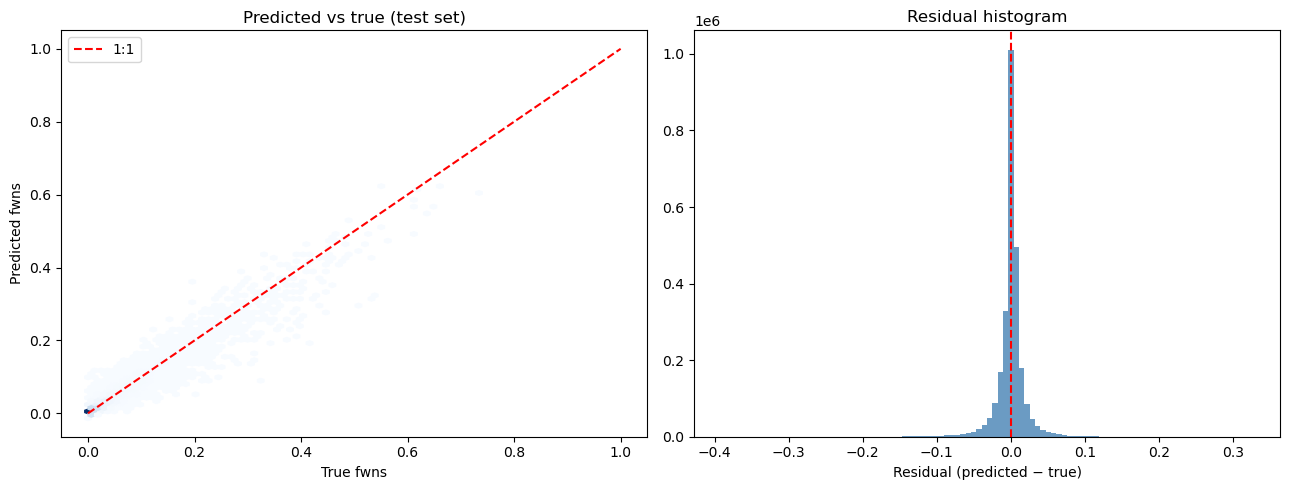

In [ ]:
# Predictions on canonical test set for error analysis
X_err_test = df_model.loc[test_idx, FINAL_FEATURE_SET]
y_err_true = y.loc[test_idx]
y_err_pred = final_model.predict(X_err_test)
residuals = y_err_pred - y_err_true.values

# Scatter predicted vs true with 2D density colouring
# Diagonal concentration = good predictions; vertical spread = high variance regime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_n = min(10000, len(y_err_true))
idx_s = np.random.choice(len(y_err_true), size=sample_n, replace=False)

axes[0].hexbin(y_err_true.values[idx_s], y_err_pred[idx_s],
               gridsize=60, cmap='Blues', mincnt=1)
axes[0].plot([0, 1], [0, 1], 'r--', label='1:1')
axes[0].set_xlabel('True fwns')
axes[0].set_ylabel('Predicted fwns')
axes[0].set_title('Predicted vs true (test set)')
axes[0].legend()

# Residual histogram: look for symmetry and fat tails
axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted − true)')
axes[1].set_title('Residual histogram')
plt.tight_layout()
plt.show()

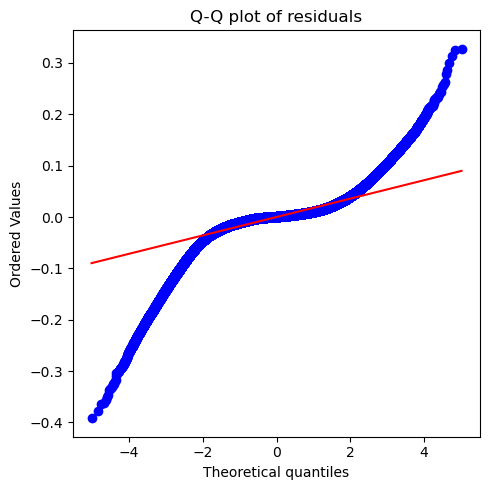

In [ ]:
# Q-Q plot: if residuals are Gaussian the points fall on the diagonal;
# curved tails indicate heavy-tailed or skewed errors
from scipy.stats import probplot
fig, ax = plt.subplots(figsize=(5, 5))
probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

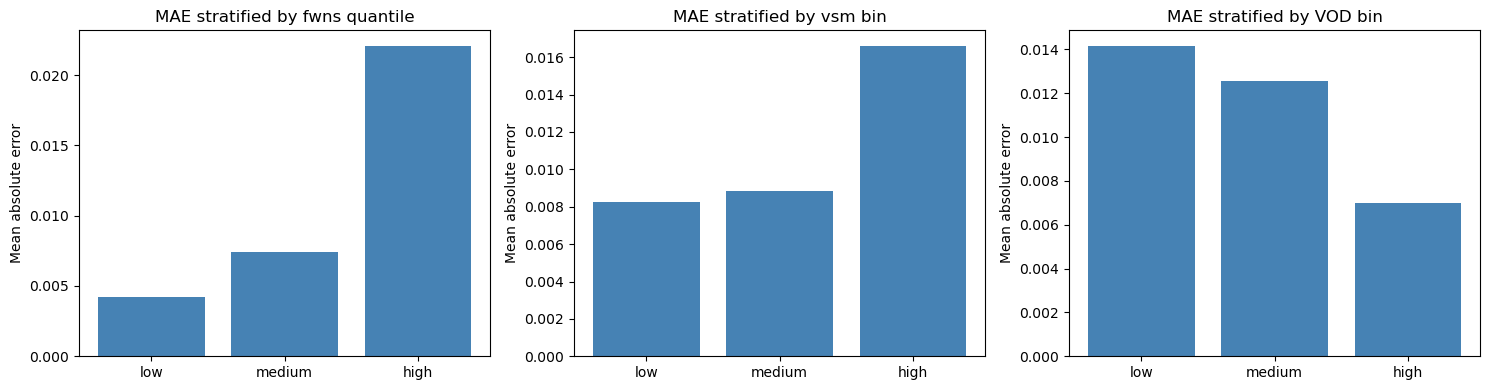

In [ ]:
# Stratified residuals by fwns quantile, vsm, and VOD
# High MAE in specific strata points to regime-dependent model weaknesses
err_df = pd.DataFrame({
    'true': y_err_true.values,
    'pred': y_err_pred,
    'abs_error': np.abs(residuals),
}, index=test_idx)
err_df['vsm'] = df_raw.loc[test_idx, 'vsm'].values
err_df['VOD'] = df_raw.loc[test_idx, 'VOD'].values

err_df['fwns_bin'] = pd.qcut(err_df['true'], q=3, labels=['low', 'medium', 'high'])
err_df['vsm_bin']  = pd.qcut(err_df['vsm'],  q=3, labels=['low', 'medium', 'high'])
err_df['vod_bin']  = pd.qcut(err_df['VOD'],  q=3, labels=['low', 'medium', 'high'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['fwns_bin', 'vsm_bin', 'vod_bin'],
                           ['fwns quantile', 'vsm bin', 'VOD bin']):
    grp = err_df.groupby(col, observed=True)['abs_error'].mean()
    ax.bar(grp.index.astype(str), grp.values, color='steelblue')
    ax.set_ylabel('Mean absolute error')
    ax.set_title(f'MAE stratified by {title}')
plt.tight_layout()
plt.show()

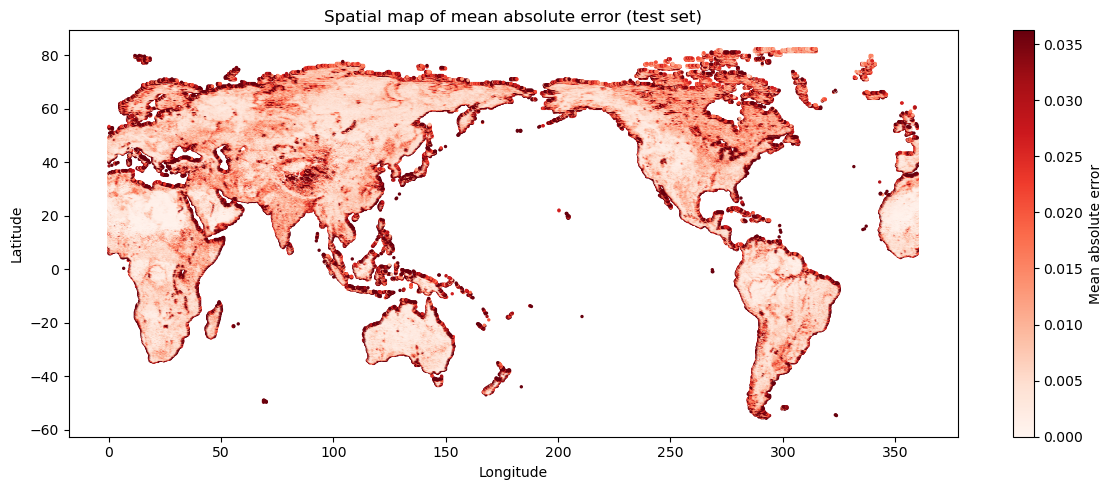

In [ ]:
# Spatial map of mean absolute error per grid cell
# Dense red regions indicate systematic spatial biases
err_df['lat'] = df_raw.loc[test_idx, 'latitude_grid'].values
err_df['lon'] = df_raw.loc[test_idx, 'longitude_grid'].values
spatial_mae = err_df.groupby(['lat', 'lon'])['abs_error'].mean().reset_index()

plt.figure(figsize=(12, 5))
sc = plt.scatter(
    spatial_mae['lon'], spatial_mae['lat'],
    c=spatial_mae['abs_error'], cmap='Reds', s=2, vmin=0, vmax=spatial_mae['abs_error'].quantile(0.95)
)
plt.colorbar(sc, label='Mean absolute error')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial map of mean absolute error (test set)')
plt.tight_layout()
plt.show()

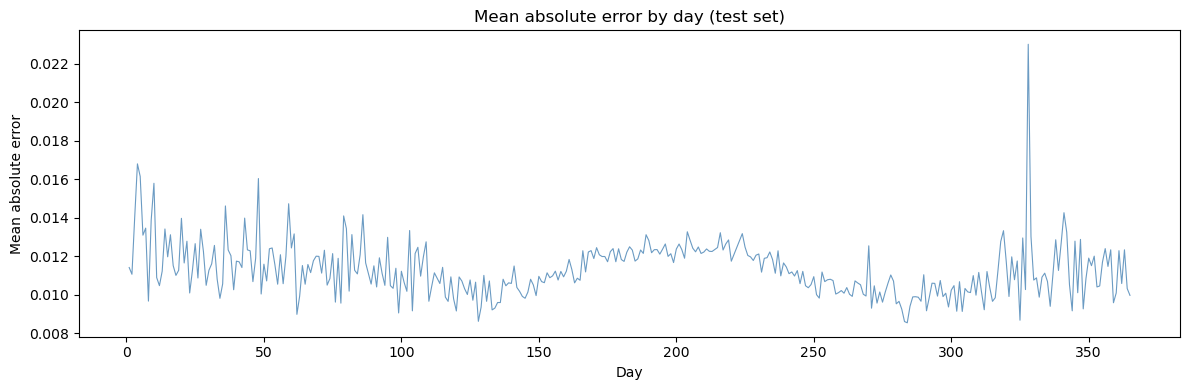

In [ ]:
# Temporal plot: mean absolute error by day
# A trend or seasonality in error suggests temporal non-stationarity
err_df['day'] = df_raw.loc[test_idx, 'day'].values
temporal_mae = err_df.groupby('day')['abs_error'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(temporal_mae['day'], temporal_mae['abs_error'],
         linewidth=0.8, color='steelblue', alpha=0.8)
plt.xlabel('Day')
plt.ylabel('Mean absolute error')
plt.title('Mean absolute error by day (test set)')
plt.tight_layout()
plt.show()

## 9. Final Model Summary


In [ ]:
# Retrain on the full dataset (train + test combined) using exhaustive HPO params
X_full = df_model[FINAL_FEATURE_SET]
y_full = y

final_model_fulldata = XGBRegressor(**{k: v for k, v in FINAL_HPO_PARAMS.items()
                                       if k not in ('objective', 'eval_metric', 'tree_method')})
final_model_fulldata.fit(X_full, y_full)
print('Retrained final model on full dataset.')
print(f'Full dataset size: {len(X_full):,} rows, {len(FINAL_FEATURE_SET)} features')

In [ ]:
# Final generalisation check on structured splits using full-data model
gen_rows = []
for split_name, tr_idx_s, te_idx_s in [
    ('temporal', train_idx_time, test_idx_time),
    ('geographic_corner', train_idx_corner, test_idx_corner),
    ('geographic_block', train_idx_block, test_idx_block),
]:
    X_te_s = df_model.loc[te_idx_s, FINAL_FEATURE_SET]
    y_te_s = y.loc[te_idx_s]
    y_pred_s = final_model_fulldata.predict(X_te_s)
    gen_rows.append({
        'split': split_name,
        'MAE_test':  mean_absolute_error(y_te_s, y_pred_s),
        'RMSE_test': root_mean_squared_error(y_te_s, y_pred_s),
        'R2_test':   r2_score(y_te_s, y_pred_s),
    })

display(pd.DataFrame(gen_rows).round(6))

In [ ]:
# Consolidated comparison table across all three model tiers
# Look for monotonic improvement from physics baseline → forward-study best → optimized

# XGBoost forward-study best on BEST_FEATURE_SET (from §5.2 results)
ref_row = feature_ranking[
    (feature_ranking['model'] == 'XGBoost') &
    (feature_ranking['feature_set'] == BEST_FEATURE_SET_NAME)
].iloc[0]

final_r2_test = r2_score(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_mae_test = mean_absolute_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_rmse_test = root_mean_squared_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)

summary_table = pd.DataFrame([
    {
        'model_tier': 'Physics baseline (DR)',
        'MAE_test':  physics_baseline_metrics['MAE'],
        'RMSE_test': physics_baseline_metrics['RMSE'],
        'R2_test':   physics_baseline_metrics['R2'],
    },
    {
        'model_tier': 'XGBoost (forward-study best)',
        'MAE_test':  ref_row['MAE_test'],
        'RMSE_test': np.sqrt(ref_row['MSE_test']),
        'R2_test':   ref_row['R2_test'],
    },
    {
        'model_tier': 'XGBoost (optimized)',
        'MAE_test':  mean_absolute_error(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
        'RMSE_test': root_mean_squared_error(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
        'R2_test':   r2_score(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
    },
    {
        'model_tier': 'XGBoost (final, full data)',
        'MAE_test':  final_mae_test,
        'RMSE_test': final_rmse_test,
        'R2_test':   final_r2_test,
    },
])
display(summary_table.round(6))

In [ ]:
# Save final model booster to disk
final_model_fulldata.get_booster().save_model(f'{MODEL_DIR}/final_model_fulldata.json')
print('Saved: final_model_fulldata.json')

Saved: final_model_fulldata.json


In [ ]:
# Pipeline summary — final cell
r2 = final_r2_test
print(
    f'Pipeline complete. Final feature set: {len(FINAL_FEATURE_SET)} features. '
    f'Final test R\u00b2: {r2:.4f}. Model saved to final_model_fulldata.json.'
)

Pipeline complete. Final feature set: 15 features. Final test R²: 0.9246. Model saved to final_model_fulldata.json.
